# 🏥 Dermatology AI Training - Optimized for 24 Classes

**EfficientNet-B4 (PyTorch)** with advanced techniques:
- ✅ Weighted Random Sampling (class imbalance fix)
- ✅ Progressive Unfreezing Strategy
- ✅ Enhanced Data Augmentation
- ✅ Discriminative Learning Rates
- ✅ Test-Time Augmentation (TTA)

**Target**: 85-90% validation accuracy

In [1]:
import os
import json
import glob
import random
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms, models
from torchvision.models import EfficientNet_B4_Weights
from sklearn.model_selection import GroupShuffleSplit
from tqdm.auto import tqdm

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

Device: cuda


## 1) Locate and extract dataset

In [2]:
import os
import glob
import zipfile
from pathlib import Path

# Fast path detection - check known locations first
EXTRACT_DIR = None

# Check if dataset is already extracted (common Kaggle pattern)
known_paths = [
    "/kaggle/input/derma-db-24class/processed",
    "/kaggle/input/dermadb-24class-v2/processed",
    "/kaggle/input/datasets/dnghongkhang/derma-db-24class/processed",
]

for path in known_paths:
    if Path(path).exists() and Path(path, "train").exists():
        EXTRACT_DIR = path
        print(f"✅ Found dataset at: {EXTRACT_DIR}")
        break

# If not found, search (but limit depth)
if not EXTRACT_DIR:
    print("Searching for dataset...")
    for root, dirs, files in os.walk("/kaggle/input", topdown=True):
        # Limit depth to avoid scanning everything
        depth = root.replace("/kaggle/input", "").count(os.sep)
        if depth > 3:
            dirs[:] = []  # Don't go deeper
            continue
        
        if "train" in dirs and "val" in dirs:
            EXTRACT_DIR = root
            print(f"✅ Found dataset at: {EXTRACT_DIR}")
            break
        
        # Check for zip files
        for file in files:
            if file.endswith('.zip') and 'derma' in file.lower():
                DATASET_ZIP = os.path.join(root, file)
                EXTRACT_DIR = "/kaggle/working/processed"
                Path(EXTRACT_DIR).mkdir(parents=True, exist_ok=True)
                
                marker = Path(EXTRACT_DIR) / ".extracted"
                if not marker.exists():
                    print(f"Extracting: {DATASET_ZIP}")
                    with zipfile.ZipFile(DATASET_ZIP, "r") as zf:
                        zf.extractall(EXTRACT_DIR)
                    marker.write_text("ok")
                print(f"✅ Extracted to: {EXTRACT_DIR}")
                break
        
        if EXTRACT_DIR:
            break

if not EXTRACT_DIR:
    raise FileNotFoundError("Dataset not found in /kaggle/input")

print(f"DATASET PATH: {EXTRACT_DIR}")

✅ Found dataset at: /kaggle/input/datasets/dnghongkhang/derma-db-24class/processed
DATASET PATH: /kaggle/input/datasets/dnghongkhang/derma-db-24class/processed


## 2) Build train/val datasets with ENHANCED augmentation

In [3]:
def unwrap_single_dir(path: str) -> str:
    p = Path(path)
    subdirs = [d for d in p.iterdir() if d.is_dir()]
    files = [f for f in p.iterdir() if f.is_file()]
    if len(subdirs) == 1 and not files:
        return str(subdirs[0])
    return str(p)

BASE_DIR = unwrap_single_dir(EXTRACT_DIR)
print("BASE_DIR:", BASE_DIR)

train_dir = None
val_dir = None

if Path(BASE_DIR, "train").exists():
    train_dir = str(Path(BASE_DIR, "train"))
if Path(BASE_DIR, "val").exists():
    val_dir = str(Path(BASE_DIR, "val"))
elif Path(BASE_DIR, "valid").exists():
    val_dir = str(Path(BASE_DIR, "valid"))
elif Path(BASE_DIR, "validation").exists():
    val_dir = str(Path(BASE_DIR, "validation"))

# EfficientNet-B4 config
weights = EfficientNet_B4_Weights.DEFAULT
IMG_SIZE = 380

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# 🔥 ENHANCED AUGMENTATION (Phase 3)
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0), ratio=(0.75, 1.33)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(30),  # Increased from 15
    
    # NEW: Color augmentation for lighting variations
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    
    # NEW: Gaussian blur for focus variations
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.3),
    
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
    
    # Increased erasing probability
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

val_tfms = transforms.Compose([
    transforms.Resize(IMG_SIZE + 20),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

VAL_SPLIT = 0.15

# Group-based split helper functions
def find_metadata_csv(base_dir: str):
    csvs = list(Path(base_dir).rglob("*.csv"))
    if not csvs:
        return None

    preferred = [
        "metadata.csv",
        "train_metadata.csv",
        "labels.csv",
        "isic_2019_training_groundtruth.csv",
    ]
    for name in preferred:
        for p in csvs:
            if p.name.lower() == name:
                return p

    for p in csvs:
        try:
            df_head = pd.read_csv(p, nrows=5)
        except Exception:
            continue
        cols = {c.lower() for c in df_head.columns}
        has_group = bool({"patient_id", "lesion_id", "patient", "lesion"} & cols)
        has_img = bool({"image", "image_id", "isic_id", "filename", "file_name", "image_name"} & cols)
        if has_group and has_img:
            return p
    return None

def build_group_map(df: pd.DataFrame):
    cols = {c.lower(): c for c in df.columns}
    group_col = None
    for key in ["patient_id", "patient", "lesion_id", "lesion"]:
        if key in cols:
            group_col = cols[key]
            break

    img_col = None
    for key in ["image", "image_id", "isic_id", "filename", "file_name", "image_name"]:
        if key in cols:
            img_col = cols[key]
            break

    if not group_col or not img_col:
        return None, None, None

    mapping = {}
    for img, grp in zip(df[img_col], df[group_col]):
        if pd.isna(img) or pd.isna(grp):
            continue
        key = str(img)
        mapping[key] = grp
        mapping[Path(key).name] = grp
        mapping[Path(key).stem] = grp

    return mapping, img_col, group_col

if train_dir and val_dir:
    train_ds = datasets.ImageFolder(train_dir, transform=train_tfms)
    val_ds = datasets.ImageFolder(val_dir, transform=val_tfms)
    class_names = train_ds.classes

    metadata_csv = find_metadata_csv(BASE_DIR)
    if metadata_csv:
        print("Found metadata:", metadata_csv)
        df = pd.read_csv(metadata_csv)
        group_map, img_col, group_col = build_group_map(df)
        if group_map:
            def groups_from_samples(samples):
                groups = set()
                missing = 0
                for path, _ in samples:
                    p = Path(path)
                    g = group_map.get(p.stem) or group_map.get(p.name)
                    if g is None:
                        missing += 1
                        continue
                    groups.add(g)
                return groups, missing

            train_groups, miss_tr = groups_from_samples(train_ds.samples)
            val_groups, miss_val = groups_from_samples(val_ds.samples)
            overlap = train_groups & val_groups
            if overlap:
                print(
                    f"[WARNING] Potential leakage: {len(overlap)} groups in both train and val."
                )
            if miss_tr + miss_val > 0:
                print(
                    f"[WARNING] Missing group for {miss_tr + miss_val} images."
                )
else:
    full_train = datasets.ImageFolder(BASE_DIR, transform=train_tfms)
    full_val = datasets.ImageFolder(BASE_DIR, transform=val_tfms)
    class_names = full_train.classes

    labels = [y for _, y in full_train.samples]

    metadata_csv = find_metadata_csv(BASE_DIR)
    use_groups = False

    if metadata_csv:
        print("Found metadata:", metadata_csv)
        df = pd.read_csv(metadata_csv)
        group_map, img_col, group_col = build_group_map(df)
        if group_map:
            groups = []
            missing = 0
            for path, _ in full_train.samples:
                p = Path(path)
                g = group_map.get(p.stem) or group_map.get(p.name)
                if g is None:
                    missing += 1
                    g = f"unknown_{len(groups)}"
                groups.append(g)

            if missing > 0:
                print(f"[WARNING] Missing group for {missing} images.")

            gss = GroupShuffleSplit(n_splits=1, test_size=VAL_SPLIT, random_state=SEED)
            train_idx, val_idx = next(gss.split(np.zeros(len(labels)), labels, groups))
            use_groups = True
            print(f"Group split using column '{group_col}'.")
        else:
            print("[WARNING] Metadata found but columns not detected. Using stratified split.")

    if not use_groups:
        idxs_by_class = {}
        for i, y in enumerate(labels):
            idxs_by_class.setdefault(y, []).append(i)

        train_idx, val_idx = [], []
        rng = random.Random(SEED)
        for y, idxs in idxs_by_class.items():
            rng.shuffle(idxs)
            n_val = max(1, int(len(idxs) * VAL_SPLIT))
            val_idx.extend(idxs[:n_val])
            train_idx.extend(idxs[n_val:])

    train_ds = Subset(full_train, train_idx)
    val_ds = Subset(full_val, val_idx)

NUM_CLASSES = len(class_names)
print("Classes:", NUM_CLASSES)
if NUM_CLASSES != 24:
    print("[WARNING] Expected 24 classes, found:", NUM_CLASSES)

BASE_DIR: /kaggle/input/datasets/dnghongkhang/derma-db-24class/processed
Classes: 24


## 3) DataLoaders with WEIGHTED SAMPLING (Phase 1)

In [4]:
# Extract labels from dataset
if isinstance(train_ds, Subset):
    base_ds = train_ds.dataset
    idxs = train_ds.indices
    labels = [base_ds.samples[i][1] for i in idxs]
else:
    labels = [y for _, y in train_ds.samples]

# 🔥 IMPROVED: Square root weighting to avoid extreme values
counts = np.bincount(labels, minlength=NUM_CLASSES)
class_weights = 1. / np.sqrt(counts + 1e-6)  # Square root instead of linear
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

print("✅ Class Weights (sqrt-based) calculated")
print(f"   Min weight: {class_weights.min():.3f}, Max weight: {class_weights.max():.3f}")

# 🔥 CRITICAL FIX: Weighted Random Sampler for balanced batches
sample_weights = [class_weights[label].item() for label in labels]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("✅ WeightedRandomSampler created")

# Optimized hyperparameters (Phase 4)
BATCH_SIZE = 32  # Increased from 16
NUM_WORKERS = 4

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,  # Use sampler instead of shuffle
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    prefetch_factor=2
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    prefetch_factor=2
)

print(f"Train batches: {len(train_loader)} (batch_size={BATCH_SIZE})")
print(f"Val batches: {len(val_loader)}")

✅ Class Weights (sqrt-based) calculated
   Min weight: 0.228, Max weight: 1.924
✅ WeightedRandomSampler created
Train batches: 1065 (batch_size=32)
Val batches: 193


## 4) Model (EfficientNet-B4)

In [5]:
model = models.efficientnet_b4(weights=weights)

# Initially freeze all backbone
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier for 24 classes
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.6, inplace=True),
    nn.Linear(in_features, NUM_CLASSES)
)

model = model.to(device)
MODEL_TAG = "efficientnet_b4_derma_best.pth"
print("✅ Model initialized (Backbone frozen initially)")
print(model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 183MB/s]


✅ Model initialized (Backbone frozen initially)
Sequential(
  (0): Dropout(p=0.6, inplace=True)
  (1): Linear(in_features=1792, out_features=24, bias=True)
)


## 5) Loss, optimizer, scheduler with DISCRIMINATIVE LR (Phase 2)

In [6]:
# Loss with improved label smoothing
criterion = nn.CrossEntropyLoss(
    weight=class_weights, 
    label_smoothing=0.1  # Increased from 0.05
)

# 🔥 DISCRIMINATIVE LEARNING RATES (Phase 2.2)
LR_CLASSIFIER = 1e-3  # Increased from 3e-4
LR_BACKBONE = 1e-4    # Increased from 5e-5
WEIGHT_DECAY = 3e-2  # Doubled for anti-overfitting

# Initially only classifier is trainable
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad], 
    lr=LR_CLASSIFIER, 
    weight_decay=WEIGHT_DECAY
)

NUM_EPOCHS = 45  # Optimal for deep learning  # Increased from 40
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, 
    T_0=10,  # Restart every 10 epochs
    T_mult=2,
    eta_min=1e-6
)

use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

print(f"✅ Optimizer: AdamW (LR_classifier={LR_CLASSIFIER}, LR_backbone={LR_BACKBONE})")
print(f"✅ Scheduler: CosineAnnealingWarmRestarts (T_0=10)")
print(f"✅ Label smoothing: 0.1")

# Test-Time Augmentation (already good!)
def tta_forward(model, images):
    logits = model(images)
    logits += model(torch.flip(images, dims=[3]))
    logits += model(torch.flip(images, dims=[2]))
    logits += model(torch.rot90(images, 1, [2,3]))
    logits += model(torch.rot90(images, 3, [2,3]))
    return logits / 5

✅ Optimizer: AdamW (LR_classifier=0.001, LR_backbone=0.0001)
✅ Scheduler: CosineAnnealingWarmRestarts (T_0=10)
✅ Label smoothing: 0.1


## 6) Train & validate with PROGRESSIVE UNFREEZING (Phase 2.1)

In [7]:
import copy
from sklearn.metrics import f1_score

PATIENCE = 8  # Higher patience to avoid premature stopping  # Increased from 7

# 🔥 PROGRESSIVE UNFREEZING SCHEDULE (Phase 2.1)
UNFREEZE_SCHEDULE = {
    1: "freeze_all",      # Epoch 1: Warm up classifier only
    2: "unfreeze_last_2", # Epoch 2: Last 2 blocks
    4: "unfreeze_last_4", # Epoch 4: Last 4 blocks  
    7: "unfreeze_all"     # Epoch 7: Full model
}

def apply_unfreeze_strategy(model, epoch):
    """Progressive unfreezing based on epoch"""
    if epoch not in UNFREEZE_SCHEDULE:
        return None
    
    strategy = UNFREEZE_SCHEDULE[epoch]
    
    if strategy == "freeze_all":
        # Already frozen
        return None
    
    elif strategy == "unfreeze_last_2":
        print(f"🔓 Epoch {epoch}: Unfreezing last 2 blocks")
        for param in model.features[-2:].parameters():
            param.requires_grad = True
        return torch.optim.AdamW([
            {'params': model.features[-2:].parameters(), 'lr': 5e-5},
            {'params': model.classifier.parameters(), 'lr': 1e-3}
        ], weight_decay=1e-2)
    
    elif strategy == "unfreeze_last_4":
        print(f"🔓 Epoch {epoch}: Unfreezing last 4 blocks")
        for param in model.features[-4:].parameters():
            param.requires_grad = True
        return torch.optim.AdamW([
            {'params': model.features[-4:].parameters(), 'lr': 1e-4},
            {'params': model.classifier.parameters(), 'lr': 1e-3}
        ], weight_decay=1e-2)
    
    elif strategy == "unfreeze_all":
        print(f"🔓 Epoch {epoch}: Unfreezing ALL layers")
        for param in model.parameters():
            param.requires_grad = True
        return torch.optim.AdamW([
            {'params': model.features[:-4].parameters(), 'lr': 5e-5},
            {'params': model.features[-4:].parameters(), 'lr': 1e-4},
            {'params': model.classifier.parameters(), 'lr': 1e-3}
        ], weight_decay=1e-2)
    
    return None

def get_class_to_idx(dataset):
    if hasattr(dataset, 'class_to_idx'): return dataset.class_to_idx
    if hasattr(dataset, 'dataset') and hasattr(dataset.dataset, 'class_to_idx'): return dataset.dataset.class_to_idx
    return None

def run_epoch(model, loader, train=True):
    all_preds = []
    all_labels = []
    
    if train:
        model.train()
    else:
        model.eval()

    running_loss = 0.0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=use_amp):
                logits = model(images)
                loss = criterion(logits, labels)
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], max_norm=0.5)  # Tighter clipping for stability
            scaler.step(optimizer)
            scaler.update()
        else:
            with torch.no_grad():
                logits = tta_forward(model, images)
                loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(all_labels)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    epoch_acc = (all_preds == all_labels).mean()
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    return epoch_loss, epoch_acc, epoch_f1

print("🚀 Starting Training with Progressive Unfreezing...")
best_val_f1 = 0.0
best_val_loss = float('inf')
val_loss_no_improve = 0
epochs_no_improve = 0
history = []

for epoch in range(1, NUM_EPOCHS + 1):
    # Apply progressive unfreezing
    new_optimizer = apply_unfreeze_strategy(model, epoch)
    if new_optimizer is not None:
        optimizer = new_optimizer
        remaining = NUM_EPOCHS - epoch + 1
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=10, T_mult=2, eta_min=1e-6
        )

    train_loss, train_acc, train_f1 = run_epoch(model, train_loader, train=True)
    val_loss, val_acc, val_f1 = run_epoch(model, val_loader, train=False)
    scheduler.step()

    history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_acc": train_acc, "train_f1": train_f1,
        "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1,
    })

    # Track val loss for early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        val_loss_no_improve = 0
    else:
        val_loss_no_improve += 1
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_no_improve = 0
        torch.save({
            "model_state": model.state_dict(),
            "class_to_idx": get_class_to_idx(train_ds),
            "val_f1": best_val_f1, "val_acc": val_acc
        }, MODEL_TAG)
        print(f"✅ Epoch {epoch} | SAVED BEST: F1={val_f1:.4f} (Acc={val_acc:.4f})")
    else:
        epochs_no_improve += 1
        
        # Overfitting detection
        train_val_gap = train_acc - val_acc
        if train_val_gap > 0.10:
            print(f"⚠️ Overfitting detected! Gap: {train_val_gap:.1%}")
    
    torch.save(model.state_dict(), "last_checkpoint.pth")
    print(f"   Train: Acc={train_acc:.4f} F1={train_f1:.4f} | Val: Acc={val_acc:.4f} F1={val_f1:.4f}")

    if epochs_no_improve >= PATIENCE:
        print(f"⏹️  Early Stopping at Epoch {epoch}.")
        break

print(f"🎉 Finished! Best F1: {best_val_f1:.4f}")

🚀 Starting Training with Progressive Unfreezing...


  0%|          | 0/1065 [00:00<?, ?it/s]

  0%|          | 0/193 [00:00<?, ?it/s]

✅ Epoch 1 | SAVED BEST: F1=0.2503 (Acc=0.4198)
   Train: Acc=0.2720 F1=0.1993 | Val: Acc=0.4198 F1=0.2503
🔓 Epoch 2: Unfreezing last 2 blocks


  0%|          | 0/1065 [00:00<?, ?it/s]

...

  0%|          | 0/193 [00:00<?, ?it/s]

⚠️ Overfitting detected! Gap: 11.3%
   Train: Acc=0.8592 F1=0.8879 | Val: Acc=0.7457 F1=0.6611


  0%|          | 0/1065 [00:00<?, ?it/s]

  0%|          | 0/193 [00:00<?, ?it/s]

✅ Epoch 45 | SAVED BEST: F1=0.6703 (Acc=0.7392)
   Train: Acc=0.8653 F1=0.8946 | Val: Acc=0.7392 F1=0.6703
🎉 Finished! Best F1: 0.6703


## 7) Save history & class mapping

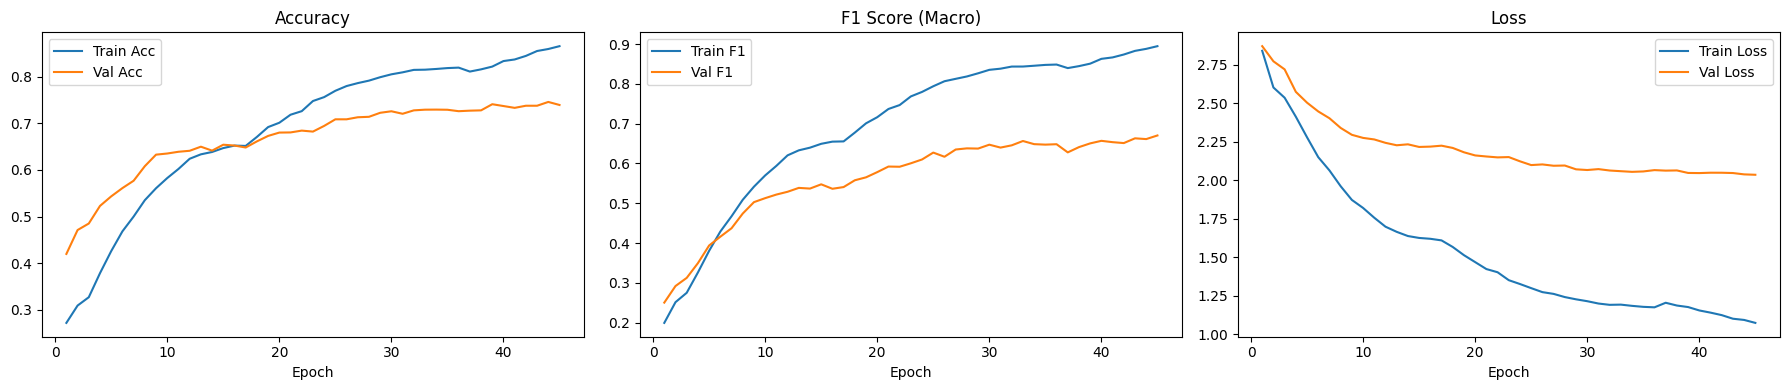

In [8]:
import json
import matplotlib.pyplot as plt

with open("training_history.json", "w") as f:
    json.dump(history, f, indent=2)

class_to_idx = None
if hasattr(train_ds, 'class_to_idx'):
    class_to_idx = train_ds.class_to_idx
elif hasattr(train_ds, 'dataset') and hasattr(train_ds.dataset, 'class_to_idx'):
    class_to_idx = train_ds.dataset.class_to_idx

if class_to_idx:
    with open("class_to_idx.json", "w") as f:
        json.dump(class_to_idx, f, indent=2)

if len(history) > 0:
    epochs = [h["epoch"] for h in history]
    train_loss = [h["train_loss"] for h in history]
    val_loss = [h["val_loss"] for h in history]
    train_acc = [h["train_acc"] for h in history]
    val_acc = [h["val_acc"] for h in history]
    train_f1 = [h["train_f1"] for h in history]
    val_f1 = [h["val_f1"] for h in history]

    plt.figure(figsize=(18, 4))
    
    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_acc, label="Train Acc")
    plt.plot(epochs, val_acc, label="Val Acc")
    plt.legend()
    plt.title("Accuracy")
    plt.xlabel("Epoch")

    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_f1, label="Train F1")
    plt.plot(epochs, val_f1, label="Val F1")
    plt.legend()
    plt.title("F1 Score (Macro)")
    plt.xlabel("Epoch")

    plt.subplot(1, 3, 3)
    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.legend()
    plt.title("Loss")
    plt.xlabel("Epoch")

    plt.tight_layout()
    plt.savefig("training_history.png", dpi=200)
    plt.show()
else:
    print("No history to plot.")

## 8) Evaluation (confusion matrix + report)

Evaluating on validation set with TTA...


  0%|          | 0/193 [00:00<?, ?it/s]


🎯 MACRO F1 SCORE: 0.6703
                           precision    recall  f1-score   support

             acne_rosacea       0.73      0.83      0.78       127
        actinic_keratosis       0.70      0.72      0.71       195
       alopecia_hair_loss       0.62      0.76      0.68        50
     basal_cell_carcinoma       0.82      0.84      0.83       547
bullous_disease_pemphigus       0.65      0.64      0.65        81
      cellulitis_impetigo       0.52      0.54      0.53        52
       contact_dermatitis       0.55      0.64      0.59        50
           dermatofibroma       0.73      0.88      0.80        50
 eczema_atopic_dermatitis       0.66      0.68      0.67       302
 exanthems_drug_eruptions       0.42      0.55      0.48        71
        fungal_infections       0.78      0.71      0.75       418
       infestations_bites       0.61      0.47      0.53        78
  lupus_connective_tissue       0.65      0.55      0.60        76
        melanocytic_nevus       0.9

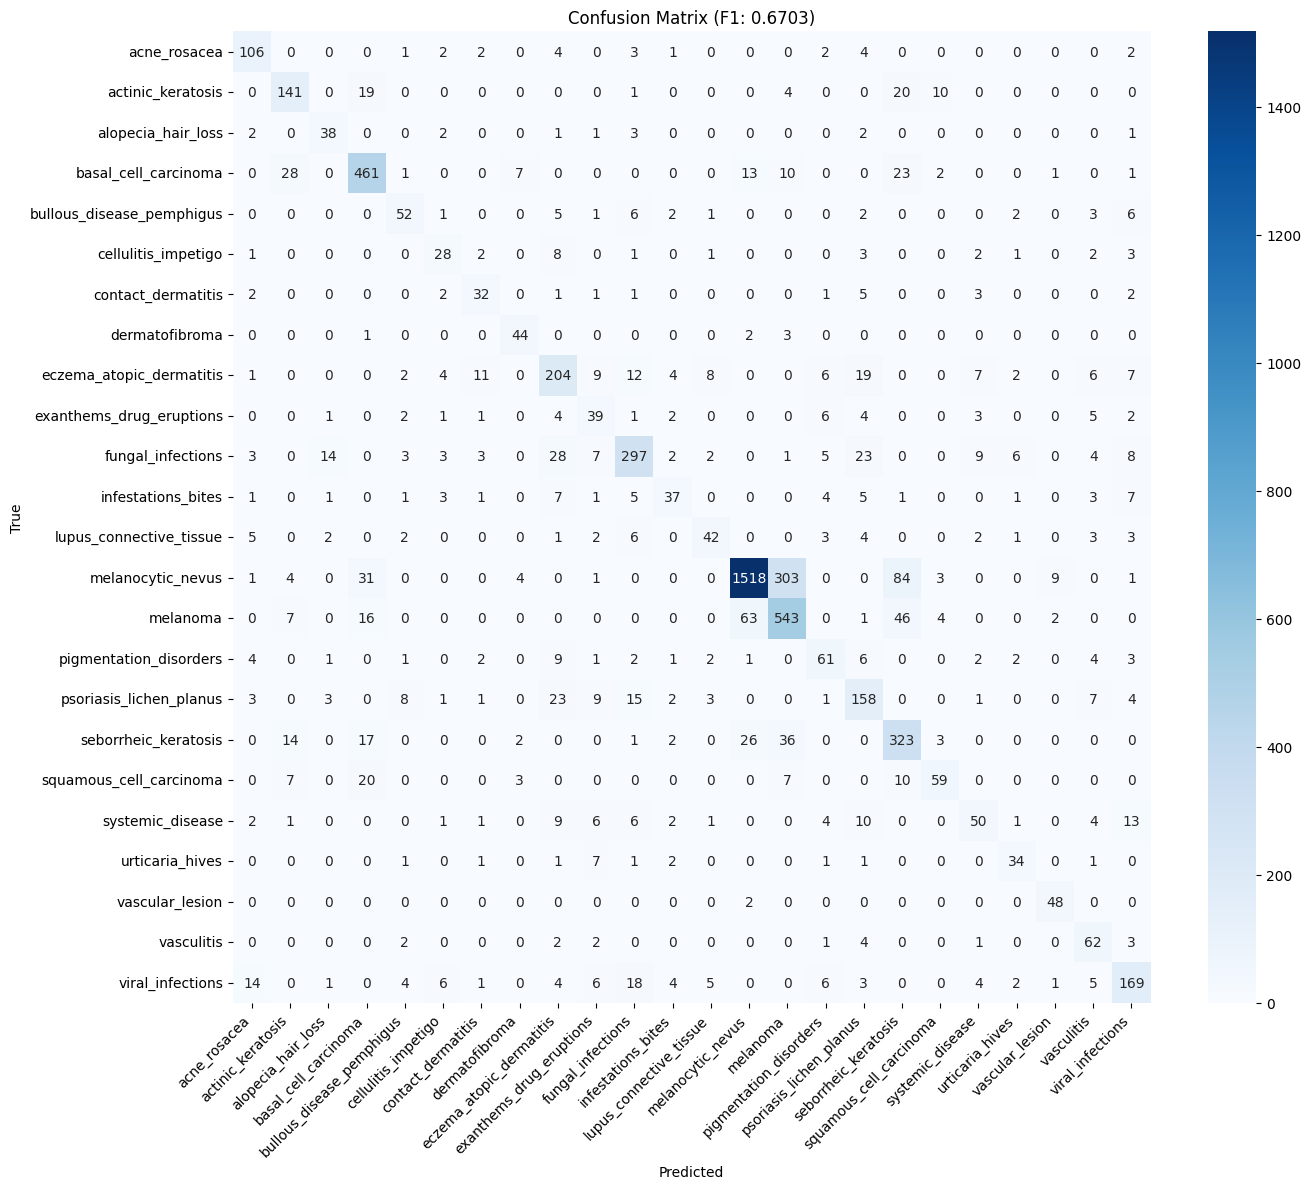

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

ckpt = torch.load(MODEL_TAG, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()

all_preds = []
all_labels = []

print("Evaluating on validation set with TTA...")
with torch.no_grad():
    for images, labels in tqdm(val_loader):
        images = images.to(device, non_blocking=True)
        logits = tta_forward(model, images)
        preds = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

macro_f1 = f1_score(all_labels, all_preds, average="macro")
print(f"\n🎯 MACRO F1 SCORE: {macro_f1:.4f}")
print("="*50)

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.title(f"Confusion Matrix (F1: {macro_f1:.4f})")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200)
plt.show()

## 9) Quick inference sanity check

/tmp/ipykernel_24/1403543201.py:27: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24/1403543201.py:27: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


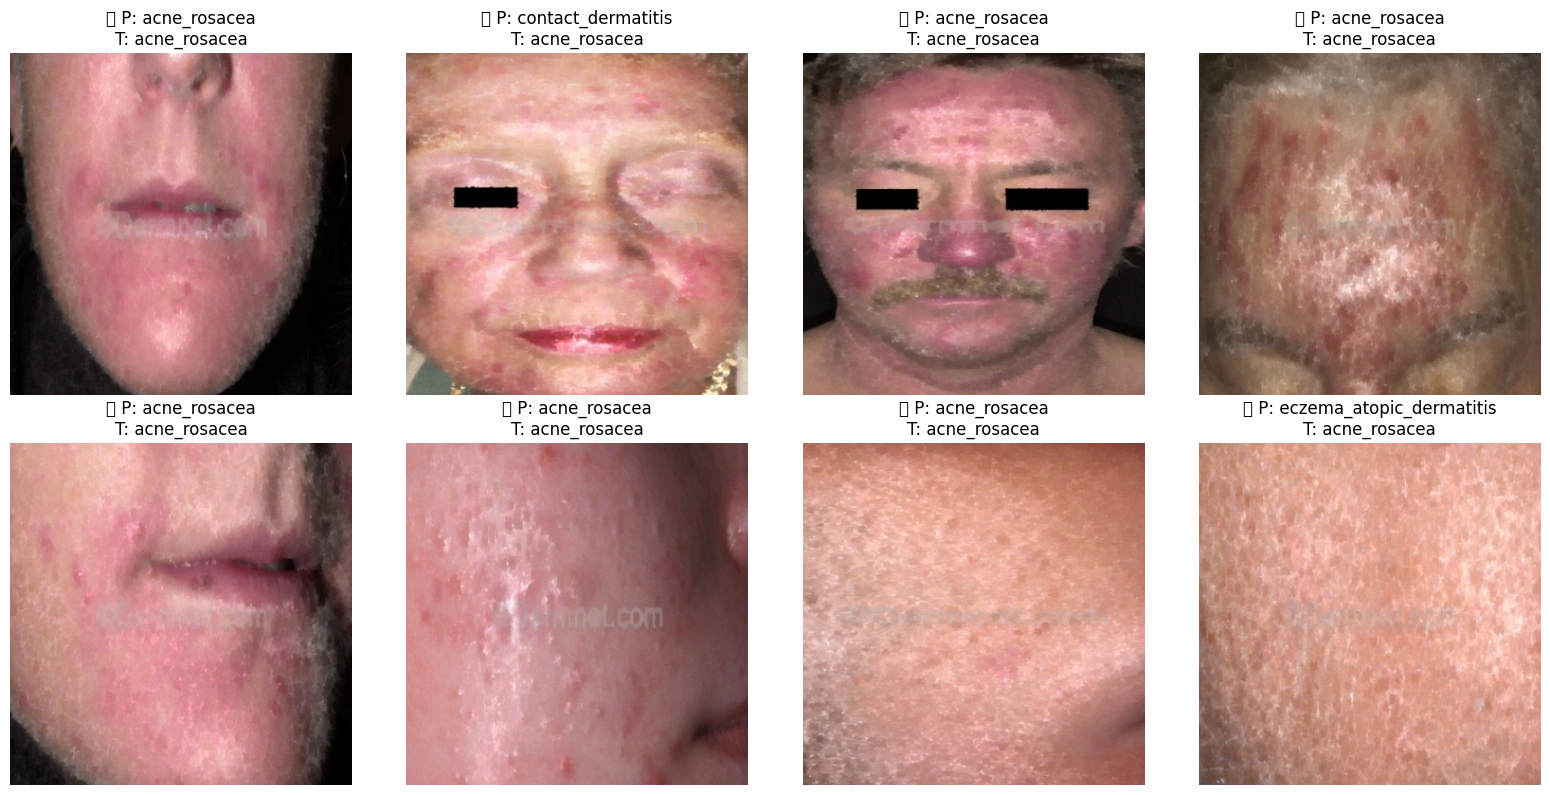

In [10]:
import matplotlib.pyplot as plt

model.eval()
images, labels = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    logits = tta_forward(model, images)
    preds = logits.argmax(1).cpu().numpy()

images = images.cpu()
labels = labels.cpu().numpy()

mean_t = torch.tensor(mean).view(3,1,1)
std_t = torch.tensor(std).view(3,1,1)

plt.figure(figsize=(16, 8))
num_show = min(8, len(images))
for i in range(num_show):
    img = images[i] * std_t + mean_t
    img = img.permute(1,2,0).clamp(0,1)
    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    correct = "✅" if preds[i] == labels[i] else "❌"
    plt.title(f"{correct} P: {class_names[preds[i]]}\nT: {class_names[labels[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## 10) Outputs

In [11]:
print("📦 Saved files:")
for p in [
    MODEL_TAG,
    "training_history.json",
    "class_to_idx.json",
    "confusion_matrix.png",
    "training_history.png",
]:
    if os.path.exists(p):
        print("-", p)

📦 Saved files:
- efficientnet_b4_derma_best.pth
- training_history.json
- class_to_idx.json
- confusion_matrix.png
- training_history.png
